In [6]:
from traceback import print_tb

import pandas as pd
from pyasn1_modules.rfc3161 import Accuracy

from Unit4 import x_train

df = pd.read_csv("C:\\Users\\dapat\\OneDrive\\Dhairya files\\sem4\\Python\\practice\\Python-2_26-main\\Dataset-1\\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [7]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
y = df["Outcome"]
x = df.drop("Outcome", axis=1)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)

In [15]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
scaler = MinMaxScaler()
x_train_scale,x_test_scale = scaler.fit_transform(X_train),scaler.fit_transform(X_test)
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train_scale,y_train)
y_pred = knn.predict(x_test_scale)
print("accuracy score is:",accuracy_score(y_test,y_pred))

accuracy score is: 0.7337662337662337


In [22]:
set = {}
for i in range(1,17):
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)
    x_train_scale,x_test_scale = scaler.fit_transform(X_train),scaler.fit_transform(X_test)
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_scale, y_train)
    y_pred = knn.predict(x_test_scale)
    set[i] = accuracy_score(y_test, y_pred)
print(set)


{1: 0.6883116883116883, 2: 0.7077922077922078, 3: 0.7077922077922078, 4: 0.7272727272727273, 5: 0.7337662337662337, 6: 0.7272727272727273, 7: 0.7142857142857143, 8: 0.7597402597402597, 9: 0.7272727272727273, 10: 0.7467532467532467, 11: 0.7597402597402597, 12: 0.7597402597402597, 13: 0.7532467532467533, 14: 0.7792207792207793, 15: 0.7727272727272727, 16: 0.7857142857142857}


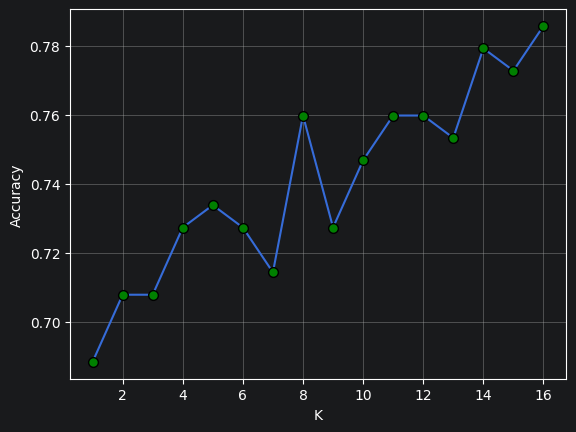

In [24]:
import matplotlib.pyplot as plt
plt.plot(range(1,17),list(set.values()),ms =7, mec = 'k', mfc = 'g',marker = 'o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [19]:
scaler = MinMaxScaler()
x_train_scale,x_test_scale = scaler.fit_transform(X_train),scaler.fit_transform(X_test)
knn = KNeighborsClassifier(n_neighbors = 18)
knn.fit(x_train_scale,y_train)
y_pred = knn.predict(x_test_scale)
print("accuracy score is:",accuracy_score(y_test,y_pred))

accuracy score is: 0.7857142857142857


# k= N^(1/2)